In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

from IPython.display import display, HTML

base_folder = ".."

## Topologies

In [2]:
def read_topology(topology_name):
    print(f"Topology name: {topology_name}")
    df = pd.read_csv(f"{base_folder}/resources/env/{topology_name}.txt", delimiter=";")
    display(HTML(df.to_html()))
        
read_topology("multi")
read_topology("single")

Topology name: multi


,ClusterID,ClusterName,Cores,Speed,Memory,numberOfHosts,memoryCapacityPerHost,coreCountPerHost
0,A01,A01,32,3.20,2048,1,256,32
1,B01,B01,48,2.93,1256,6,64,8
2,C01,C01,32,3.20,2048,2,128,16


Topology name: single


,ClusterID,ClusterName,Cores,Speed,Memory,numberOfHosts,memoryCapacityPerHost,coreCountPerHost
0,A01,A01,8,3.2,128,1,128,8


## Failure

In [14]:
def milli_to_day(inp):
    return timedelta(milliseconds=inp)


def read_failure(failure_name):
    print(f"Failure name: {failure_name}")
    df = pd.read_csv(f"{base_folder}/resources/failure_traces/{failure_name}.csv", delimiter=",")
    
    df["start_day"] = df["start"].apply(milli_to_day)
    df["duration_day"] = df["duration"].apply(milli_to_day)
    df["end_day"] = df["start_day"] + df["duration_day"]
    
    display(HTML(df.to_html()))
    return df
        
failure_trace = read_failure("single_failure")

Failure name: single_failure


,start,duration,intensity,start_day,duration_day,end_day
0,86400000,86400000,0.6,1 days,1 days,2 days


## Traces

In [15]:
df_trace = pd.read_parquet(f"{base_folder}/resources/bitbrains-small/trace/trace.parquet")
df_trace.head()

,id,timestamp,duration,cpu_count,cpu_usage
0,1019,2013-08-12 13:40:46+00:00,300000,1,0.000000
1,1019,2013-08-12 13:45:46+00:00,300000,1,11.703998
2,1019,2013-08-12 13:55:46+00:00,600000,1,0.000000
3,1019,2013-08-12 14:00:46+00:00,300000,1,11.703998
4,1019,2013-08-12 14:15:46+00:00,900000,1,0.000000


In [16]:
df_meta = pd.read_parquet(f"{base_folder}/resources/bitbrains-small/trace/meta.parquet")
df_meta.head()

,id,start_time,stop_time,cpu_count,cpu_capacity,mem_capacity
0,1019,2013-08-12 13:35:46+00:00,2013-09-11 13:39:58+00:00,1,2926.000135,181352
1,1023,2013-08-12 13:35:46+00:00,2013-09-11 13:39:58+00:00,1,2925.999560,260096
2,1026,2013-08-12 13:35:46+00:00,2013-09-11 13:39:58+00:00,1,2925.999717,249972
3,1052,2013-08-29 14:38:12+00:00,2013-09-05 07:09:07+00:00,1,2926.000107,131245
4,1073,2013-08-21 11:07:12+00:00,2013-09-11 13:39:58+00:00,1,2599.999649,179306


# Lets run this in OpenDC!

## Load Resulting Files

In [244]:
output_folder = f"{base_folder}/output"
workload = "workload=bitbrains-small"
seed = "seed=0"

df_host_single = pd.read_parquet(f"{output_folder}/host/topology=single/{workload}/{seed}/data.parquet")
df_host_multi = pd.read_parquet(f"{output_folder}/host/topology=multi/{workload}/{seed}/data.parquet")

df_server_single = pd.read_parquet(f"{output_folder}/server/topology=single/{workload}/{seed}/data.parquet")
df_server_multi = pd.read_parquet(f"{output_folder}/server/topology=multi/{workload}/{seed}/data.parquet")

df_service_single = pd.read_parquet(f"{output_folder}/service/topology=single/{workload}/{seed}/data.parquet")
df_service_multi = pd.read_parquet(f"{output_folder}/service/topology=multi/{workload}/{seed}/data.parquet")

def add_absolute_timestamp(df, start_dt):
    df["absolute_timestamp"] = start_dt + (df["timestamp"] - df["timestamp"].min())

add_absolute_timestamp(df_host_single, df_meta["start_time"].min())
add_absolute_timestamp(df_host_multi, df_meta["start_time"].min())

add_absolute_timestamp(df_server_single, df_meta["start_time"].min())
add_absolute_timestamp(df_server_multi, df_meta["start_time"].min())

add_absolute_timestamp(df_service_single, df_meta["start_time"].min())
add_absolute_timestamp(df_service_multi, df_meta["start_time"].min())

## Determine worktime

In [245]:
def get_opendc_worktime(df_server, server_name):
    df = df_server_single[df_server_single["server_name"] == server_name].reset_index()
    df_server_filtered = df[df["host_id"].notnull()]

    if (len(df_server_filtered) == 0):
        print("server has not been run")
        return None
    
    df["diff"] = df.uptime.diff()
    
    uptime_changes = df[df["diff"] != 0]
    
    first_sample = df[df["uptime"] > 0].min()
    start_server = first_sample.timestamp.to_pydatetime().replace(tzinfo=None) - \
                        timedelta(milliseconds=int(first_sample.uptime))
    
    
    # This means the server was suspended due to failure
    if len(uptime_changes) == 3:
        start_suspend = uptime_changes.iloc[1].timestamp.to_pydatetime().replace(tzinfo=None)
        
        end_suspend = uptime_changes.iloc[2]
        end_suspend = end_suspend.timestamp.to_pydatetime().replace(tzinfo=None) - \
                        timedelta(milliseconds=int(end_suspend.uptime))
        
        end_server = df.timestamp.max().to_pydatetime().replace(tzinfo=None)
        first_worktime = start_suspend - start_server 
        second_worktime = end_server - end_suspend
        total_worktime = first_worktime + second_worktime
        
        
        print(f"{start_server = }")
        print(f"{start_suspend = }")
        print(f"{first_worktime = }")
        
        print(f"{end_suspend = }")
        print(f"{end_server = }")
        print(f"{second_worktime = }")
        print(f"{total_worktime = }")
        
    else:
        end_server = df.timestamp.max().to_pydatetime().replace(tzinfo=None)
        total_worktime = end_server - start_server
        
    return total_worktime


def compare_worktime(df_meta, df_server, server_name):
    opendc_worktime = get_opendc_worktime(df_server, server_name)
    
    if opendc_worktime == None:
        return None
    
    df_meta_filtered = df_meta[df_meta["id"] == server_name].iloc[0]
    required_worktime = df_meta_filtered["stop_time"].to_pydatetime().replace(tzinfo=None) \
            - df_meta_filtered["start_time"].to_pydatetime().replace(tzinfo=None)
    
    print(f"{opendc_worktime = }")
    print(f"{required_worktime = }")
    print(f"{opendc_worktime - required_worktime }")
    return opendc_worktime - required_worktime 
    
deltas = []

for s in df_server_single.server_name.unique():
    deltas.append(compare_worktime(df_meta, df_server_single, s))
    print(f"server {s} time: {deltas[-1]}")
    
    break

start_server = datetime.datetime(1970, 1, 1, 0, 0)
start_suspend = datetime.datetime(1970, 1, 11, 0, 0)
first_worktime = datetime.timedelta(days=10)
end_suspend = datetime.datetime(1970, 3, 8, 0, 25)
end_server = datetime.datetime(1970, 3, 30, 12, 50)
second_worktime = datetime.timedelta(days=22, seconds=44700)
total_worktime = datetime.timedelta(days=32, seconds=44700)
opendc_worktime = datetime.timedelta(days=32, seconds=44700)
required_worktime = datetime.timedelta(days=30, seconds=252)
2 days, 12:20:48
server 1019 time: 2 days, 12:20:48


In [ ]:
2592252000




# def get_server_worktime(df_meta, df_service, failure_trace, df_server, server_name):
#     start_suspend = failure_trace["start_day"].iloc[0]
#     end_suspend = failure_trace["end_day"].iloc[0]
#     suspend_duration = failure_trace.duration_day.iloc[0] 
    
#     df_meta_filtered = df_meta[df_meta["id"] == server_name].iloc[0]
#     required_worktime = df_meta_filtered["stop_time"].to_pydatetime().replace(tzinfo=None) \
#             - df_meta_filtered["start_time"].to_pydatetime().replace(tzinfo=None)
        
#     df_server_filtered = df_server[df_server["server_name"] == server_name]
#     df_server_filtered = df_server_filtered[df_server_filtered["host_id"].notnull()]

#     if (len(df_server_filtered) == 0):
#         print("server has not been run")
#         return
    
#     first_sample = df_server_filtered[df_server_filtered["timestamp"] == df_server_filtered["timestamp"].min()].iloc[0]
#     start_server = first_sample.timestamp.to_pydatetime().replace(tzinfo=None) - \
#                     timedelta(milliseconds=int(first_sample.uptime))
#     end_server = df_server_filtered.timestamp.max().to_pydatetime().replace(tzinfo=None)
#     opendc_worktime = end_server - start_server
    

#     if start_server <= (datetime(1970, 1, 1) + start_suspend):
#         print(f"FAILED SERVER")
#         opendc_no_fail = opendc_worktime - suspend_duration

#         print(f"start time:        {str(start_server)}")
#         print(f"Required worktime: {str(required_worktime)}")
#         print(f"OpenDC worktime:   {str(opendc_worktime)}")
#         print(f"Suspend time:      {suspend_duration}")
#         print(f"OpenDC non-fail:   {str(opendc_no_fail)}")
        
#         print(f"Difference:        {opendc_no_fail - required_worktime}")
        
#     else:
#         return
#         print(f"start time:        {str(start_server)}")
#         print(f"Required worktime: {str(required_worktime)}")
#         print(f"OpenDC worktime:   {str(opendc_worktime)}")
        
#         print(f"Difference:        {opendc_worktime - required_worktime}")



864000000
6135000000


In [182]:
df_1019 = df_server_single[df_server_single["server_name"] == "1019"]


df_1019["diff"] = df_1019.uptime.diff()


df_1019.iloc[-1].timestamp - df_1019[df_1019["diff"] != 0].iloc[-1].timestamp

/tmp/ipykernel_178014/843195703.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1019["diff"] = df_1019.uptime.diff()


Timedelta('29 days 23:55:00')

### Host

In [93]:
df_service_single["diff"] = df_service_single["hosts_up"].diff()

In [94]:
start_simulation = df_service_single[df_service_single["diff"] != 0].iloc[0].timestamp
start_suspend = df_service_single[df_service_single["diff"] != 0].iloc[1].timestamp
end_suspend = df_service_single[df_service_single["diff"] != 0].iloc[2].timestamp


print(f"{start_simulation = }")
print(f"{start_suspend = }")
print(f"{end_suspend = }")
print(f"{start_suspend - start_simulation = }")
print(f"{end_suspend - start_suspend = }")

start_simulation = Timestamp('1970-01-01 00:05:00+0000', tz='UTC')
start_suspend = Timestamp('1970-01-02 00:00:00+0000', tz='UTC')
end_suspend = Timestamp('1970-01-03 00:00:00+0000', tz='UTC')
start_suspend - start_simulation = Timedelta('0 days 23:55:00')
end_suspend - start_suspend = Timedelta('1 days 00:00:00')


In [25]:
display(list(df_host_multi.columns))
print(f"number of measurements: {len(df_host_multi)}")

['timestamp',
 'host_id',
 'cpu_count',
 'mem_capacity',
 'guests_terminated',
 'guests_running',
 'guests_error',
 'guests_invalid',
 'cpu_limit',
 'cpu_usage',
 'cpu_demand',
 'cpu_utilization',
 'cpu_time_active',
 'cpu_time_idle',
 'cpu_time_steal',
 'cpu_time_lost',
 'power_total',
 'uptime',
 'downtime',
 'boot_time',
 'absolute_timestamp']

number of measurements: 79560


### Server

In [26]:
display(list(df_server_multi.columns))
print(f"number of measurements: {len(df_server_multi)}")

['timestamp',
 'server_id',
 'host_id',
 'mem_capacity',
 'cpu_count',
 'cpu_limit',
 'cpu_time_active',
 'cpu_time_idle',
 'cpu_time_steal',
 'cpu_time_lost',
 'uptime',
 'downtime',
 'provision_time',
 'boot_time',
 'absolute_timestamp']

number of measurements: 409130


### Service

In [27]:
display(list(df_service_single.columns))
print(f"number of measurements: {len(df_host_single)}")

['timestamp',
 'hosts_up',
 'hosts_down',
 'servers_pending',
 'servers_active',
 'attempts_success',
 'attempts_failure',
 'attempts_error',
 'absolute_timestamp']

number of measurements: 46122


## Power Usage

In [6]:
print(f"single topology:  {df_host_single.power_total.sum()}")
print(f"multi topology:   {df_host_multi.power_total.sum()}")

single topology:  2739082800.15
multi topology:   8320518300.6


## CPU usage

In [8]:
print(f"single topology:  {df_host_single.cpu_utilization.mean()}")
print(f"multi topology:   {df_host_multi.cpu_utilization.mean()}")

single topology:  0.9889355207935903
multi topology:   0.9677045997610514


## CPU utilization

In [9]:
print(f"multi topology:   {df_host_multi.cpu_utilization.mean()}")
print(f"single topology: {df_host_single.cpu_utilization.mean()}")

multi topology:   0.9677045997610514
single topology: 0.9889355207935903


## Plotting Results

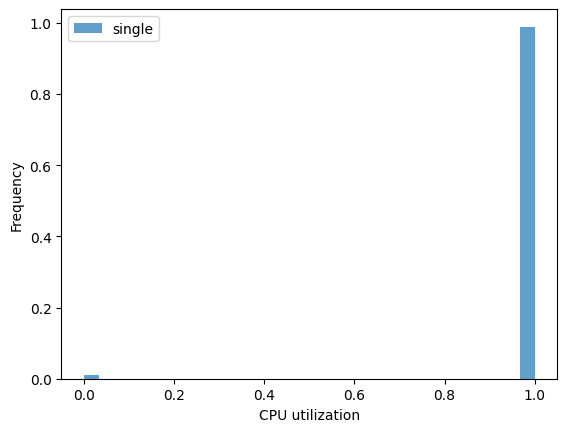

In [10]:
# data = df_host_multi.cpu_utilization
# plt.hist(data, weights=np.ones_like(data) / len(data),
#          alpha=0.7, label="multi", bins=30)


data = df_host_single.cpu_utilization
plt.hist(data, weights=np.ones_like(data) / len(data),
         alpha=0.7, label="single", bins=30)

plt.xlabel("CPU utilization")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [11]:
df_1019 = df_server_single[df_server_single["server_name"] == "1019"]
len(df_1019)

26210

In [12]:
df_1019[df_1019["timestamp"] == "1970-01-07 22:35:00+00:00"]

,timestamp,server_id,server_name,host_id,mem_capacity,cpu_count,cpu_limit,cpu_time_active,cpu_time_idle,cpu_time_steal,cpu_time_lost,uptime,downtime,provision_time,boot_time,absolute_timestamp
86490,1970-01-07 22:35:00+00:00,00000000-0000-0000-06c4-5d188009454f,1019,e220a839-7b1d-cdaf-0000-000000000000,181,1,0.0,0,0,0,0,0,0,1970-01-02 00:00:00+00:00,NaT,2013-08-19 12:05:46+00:00


In [13]:
df_server_single[df_server_single["uptime"] == -599700000]

,timestamp,server_id,server_name,host_id,mem_capacity,cpu_count,cpu_limit,cpu_time_active,cpu_time_idle,cpu_time_steal,cpu_time_lost,uptime,downtime,provision_time,boot_time,absolute_timestamp


In [14]:
df_service_single[df_service_single["timestamp"] == "1970-01-07 22:40:00+00:00"]

,timestamp,hosts_up,hosts_down,servers_pending,servers_active,attempts_success,attempts_failure,attempts_error,absolute_timestamp
1999,1970-01-07 22:40:00+00:00,1,0,25,18,33,1,0,2013-08-19 12:10:46+00:00


In [15]:
df_host_single[df_host_single["timestamp"] == "1970-01-07 22:40:00+00:00"]

,timestamp,host_id,cpu_count,mem_capacity,guests_terminated,guests_running,guests_error,guests_invalid,cpu_limit,cpu_usage,...,cpu_utilization,cpu_time_active,cpu_time_idle,cpu_time_steal,cpu_time_lost,power_total,uptime,downtime,boot_time,absolute_timestamp
1999,1970-01-07 22:40:00+00:00,e220a839-7b1d-cdaf-0000-000000000000,8,128000,0,18,0,0,25600.0,25600.0,...,1.0,2400,0,40800,0,105000.0,300000,0,1970-01-03 00:00:00+00:00,2013-08-19 12:10:46+00:00


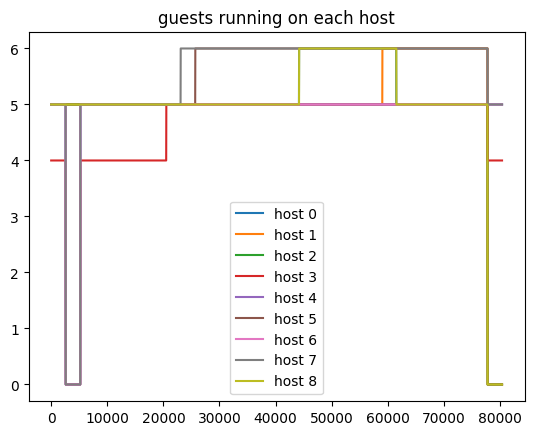

In [16]:
for i, (g,s) in enumerate(df_host_multi.groupby("host_id")):
    plt.plot(s.guests_running, label=f"host {i}")

plt.legend()
plt.title("guests running on each host")
plt.show()

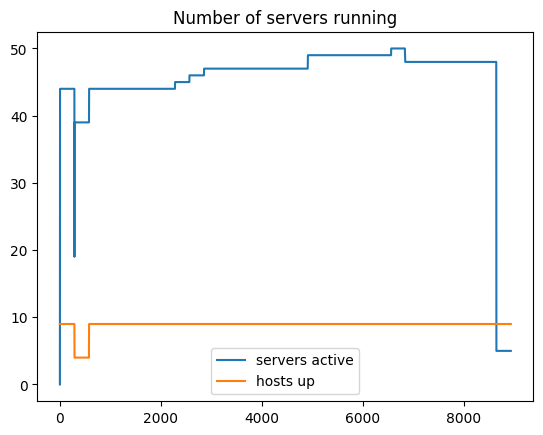

In [102]:
plt.plot(df_service_multi.servers_active, label="servers active")
plt.plot(df_service_multi.hosts_up, label="hosts up")

plt.legend()
plt.title("Number of servers running")
plt.show()

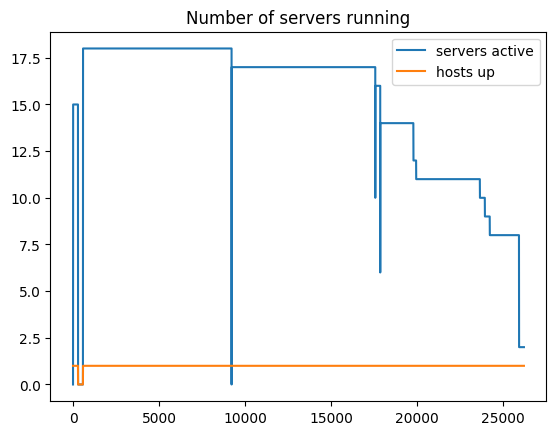

In [103]:
plt.plot(df_service_single.servers_active, label="servers active")
plt.plot(df_service_single.hosts_up, label="hosts up")

plt.legend()
plt.title("Number of servers running")
plt.show()

In [128]:
df_1019 = df_server_single[df_server_single["server_name"] == "1019"]
df_1019.uptime.sum()

2591700000

In [103]:
30 days 00:04:12

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (3402231445.py, line 1)

In [129]:
from datetime import timedelta

timedelta(seconds=3191700.000)

datetime.timedelta(days=36, seconds=81300)

In [135]:
timedelta(seconds=2591700.000)

datetime.timedelta(days=29, seconds=86100)

<AxesSubplot: >

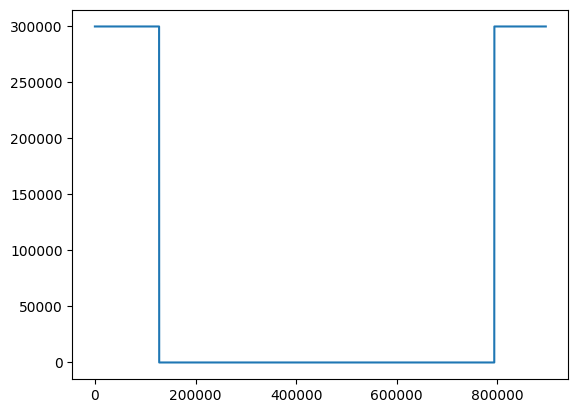

In [246]:
df_1019 = df_server_single[df_server_single["server_name"] == "1019"]

df_1019[df_1019["uptime"] >= 0].uptime.plot()
# df_server_single.uptime.plot()

In [69]:
str(timedelta(milliseconds=int(df_1019.uptime.sum())))

'29 days, 23:55:00'

In [121]:
def get_worktime(df_server, server_name):
    df = df_server_single[df_server_single["server_name"] == server_name].reset_index()
    
    df["diff"] = df.uptime.diff()
    
    uptime_changes = df[df["diff"] != 0]
    
    first_sample = df[df["uptime"] > 0].min()
    start_server = first_sample.timestamp.to_pydatetime().replace(tzinfo=None) - \
                        timedelta(milliseconds=int(first_sample.uptime))
    
    # This means the server was suspended due to failure
    if len(uptime_changes) == 3:
        start_suspend = uptime_changes.iloc[1].timestamp.replace(tzinfo=None)
        
        end_suspend = uptime_changes.iloc[2]
        end_suspend = end_suspend.timestamp.to_pydatetime().replace(tzinfo=None) - \
                        timedelta(milliseconds=int(end_suspend.uptime))
        
        end_server = df.timestamp.max().replace(tzinfo=None)
        first_worktime = start_suspend - start_server 
        second_worktime = end_server - end_suspend
        total_worktime = first_worktime + second_worktime
    
    else:
        end_server = df.timestamp.max().to_pydatetime().replace(tzinfo=None)
        total_worktime = end_server - start_server
        
    return total_worktime

get_worktime(df_server_single, "1019")

Timedelta('30 days 00:00:00')

In [243]:
def calc_new_time(work_time, check_wait, check_time):
    num_checks = int(work_time / check_wait) - 2
    
    return work_time + (check_time * num_checks)
    
def calc_last_checkpoint(processed_time, check_wait, check_time):
    total_check_time = (check_wait + check_time)
    num_checks = int(processed_time / total_check_time)
    
    return num_checks * total_check_time 

    
work_time = 864000000 * 3
check_time = 300000
check_wait = 3600000

new_worktime = calc_new_time(work_time, check_wait, check_time)

print(f"checkpoint making delay: {new_worktime - work_time}")


processed_time = 864000000
last_check = calc_last_checkpoint(processed_time, check_wait, check_time)

print(f"backtrack delay: {processed_time - last_check}")

checkpoint making delay: 215400000
backtrack delay: 2100000


In [240]:
864000000 / 1000 / 60 / 60

240.0

In [236]:
timedelta(milliseconds=215400000)

datetime.timedelta(days=2, seconds=42600)